## Experiment: OLS vs. SGD Under Ill-Conditioned Data

This notebook compares two ways of fitting the same linear regression model:

- **Closed-form OLS** — solve the normal equations directly for the coefficients that minimize squared error.
- **SGD** — learn the coefficients iteratively with gradient descent, the way `tiny-torch` trains any model.

Both are fit on two versions of the same synthetic problem: one with **ill-conditioned** features (highly correlated / multicollinear) and one with **well-conditioned** features (independent). Comparing the two fitting methods across both conditioning regimes isolates what ill-conditioning actually breaks: prediction accuracy, coefficient accuracy, or coefficient *stability*.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Configuration
NOISE = 2.0
SEED = 777
DATASET_SIZE = 100
SPLIT_RATIO = 0.9
rng = np.random.default_rng(SEED)

In [ ]:
# Function to estimate: y = 2*x + 2, applied independently to each of the 2 input features
def f(x: np.ndarray) -> np.ndarray:
    return x * 2 + 2

W_true = np.array([[2.0, 0.0], [0.0, 2.0]])
b_true = np.array([2.0, 2.0])
coefs_true = np.vstack([W_true, b_true])  # rows: [w0; w1; bias], shape (3, 2)

## Dataset

Each dataset is generated from the same known linear function with added noise, then split into a 90% training set and a 10% test set.

- **Ill-conditioned dataset.** The two input features are constructed to be almost perfectly correlated — the classic recipe for multicollinearity.
- **Well-conditioned dataset.** The two input features are drawn independently.

The helper below builds the tensors/dataloaders the same way for both cases, so the feature matrix `X` is the only thing that differs between the two experiments.

In [ ]:
from thorcino.dataset import DataLoader, TensorDataset
from thorcino.tensor import Tensor

BATCH_SIZE = 1

def build_dataset(X: np.ndarray, noise: float, split_ratio: float, rng: np.random.Generator):
    """Split (X, f(X)) into train/test tensors + dataloaders, with noise added to the targets."""
    y = f(X)
    split_idx = int(len(X) * split_ratio)

    X_tr, X_te = Tensor(X[:split_idx]), Tensor(X[split_idx:])
    y_tr, y_te = Tensor(y[:split_idx]), Tensor(y[split_idx:])

    y_tr = y_tr + rng.uniform(-1, 1, y_tr.shape) * noise
    y_te = y_te + rng.uniform(-1, 1, y_te.shape) * noise

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), BATCH_SIZE)
    test_loader = DataLoader(TensorDataset(X_te, y_te), BATCH_SIZE)
    return X_tr, X_te, y_tr, y_te, train_loader, test_loader

In [ ]:
"""Ill-conditioned dataset: x1 is x0 plus a tiny perturbation, making the two columns nearly collinear."""
EPS = 1e-4

x0 = np.linspace(-5, 5, DATASET_SIZE)
x1 = x0 + EPS * rng.standard_normal(DATASET_SIZE)
X_ill = np.stack([x0, x1]).T

X_tr_ill, X_te_ill, y_tr_ill, y_te_ill, train_loader_ill, test_loader_ill = build_dataset(
    X_ill, NOISE, SPLIT_RATIO, rng
)

print(f'X.shape: {X_ill.shape}')
print(f'X_tr.shape: {X_tr_ill.shape}, X_te.shape: {X_te_ill.shape}')
print(f'condition number: k(X) = {np.linalg.cond(X_ill):.3e}')

X.shape: (100, 2)
X_tr.shape: (90, 2), X_te.shape: (10, 2)
condition number: k(X) = 5.397e+04


In [ ]:
"""Well-conditioned dataset: x0 and x1 are drawn independently."""
x0 = rng.uniform(-5, 5, DATASET_SIZE)
x1 = rng.uniform(-5, 5, DATASET_SIZE)
X_well = np.stack([x0, x1]).T

X_tr_well, X_te_well, y_tr_well, y_te_well, train_loader_well, test_loader_well = build_dataset(
    X_well, NOISE, SPLIT_RATIO, rng
)

print(f'X.shape: {X_well.shape}')
print(f'X_tr.shape: {X_tr_well.shape}, X_te.shape: {X_te_well.shape}')
print(f'condition number: k(X) = {np.linalg.cond(X_well):.3e}')

X.shape: (100, 2)
X_tr.shape: (90, 2), X_te.shape: (10, 2)
condition number: k(X) = 1.095e+00


### Feature correlation: ill vs. well conditioned

The scatter plots below make the difference in conditioning visible directly: the ill-conditioned features fall almost exactly on a line (x1 ≈ x0), while the well-conditioned features fill the plane.

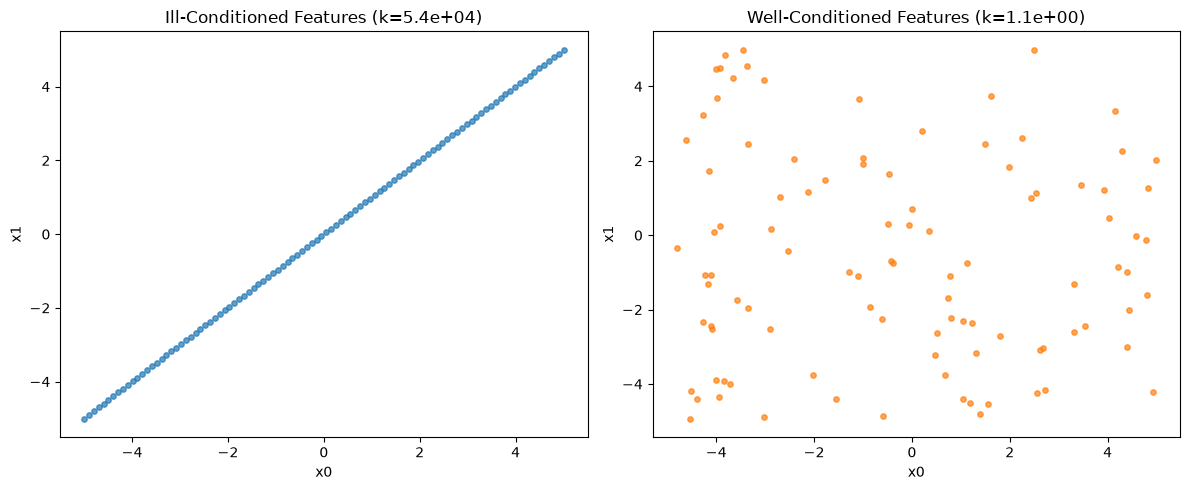

In [ ]:
fig, (ax_feat_ill, ax_feat_well) = plt.subplots(1, 2, figsize=(12, 5))

ax_feat_ill.scatter(X_ill[:, 0], X_ill[:, 1], s=15, alpha=0.7)
ax_feat_ill.set_title(f"Ill-Conditioned Features (k={np.linalg.cond(X_ill):.1e})")
ax_feat_ill.set_xlabel("x0")
ax_feat_ill.set_ylabel("x1")

ax_feat_well.scatter(X_well[:, 0], X_well[:, 1], s=15, alpha=0.7, color='C1')
ax_feat_well.set_title(f"Well-Conditioned Features (k={np.linalg.cond(X_well):.1e})")
ax_feat_well.set_xlabel("x0")
ax_feat_well.set_ylabel("x1")

fig.tight_layout()
plt.show()

## Method 1: Closed-Form OLS

Ordinary Least Squares solves for the coefficients that minimize squared error directly, via the normal equations:

$$\hat{\beta} = (X^\top X)^{-1} X^\top y$$

where a column of ones is appended to `X` so the bias is estimated along with the weights.

This closed-form estimator is exact for well-behaved data, but it is also the textbook example of numerical instability under multicollinearity: the condition number of `XᵀX` is the **square** of the condition number of `X`, so any noise in `y` gets amplified enormously once the columns of `X` are nearly collinear.


In [ ]:
def fit_ols(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Solve the normal equations beta = (X^T X)^-1 X^T y, with a bias column appended to X."""
    A = np.hstack([X, np.ones((X.shape[0], 1))])
    beta = np.linalg.inv(A.T @ A) @ A.T @ y
    return beta  # shape (n_features + 1, n_outputs); last row is the bias

In [ ]:
ols_ill = fit_ols(X_tr_ill.data, y_tr_ill.data)
ols_well = fit_ols(X_tr_well.data, y_tr_well.data)

print('\nTrue coefficients:\n', coefs_true)
print('\nOLS coefficients (ill-conditioned data):\n', ols_ill)
print('\nOLS coefficients (well-conditioned data):\n', ols_well)


True coefficients:
 [[2. 0.]
 [0. 2.]
 [2. 2.]]

OLS coefficients (ill-conditioned data):
 [[-198.44038922  129.5575668 ]
 [ 200.38653886 -127.52593288]
 [   1.76287341    2.10374302]]

OLS coefficients (well-conditioned data):
 [[ 1.94220652  0.00388477]
 [-0.08058618  2.03873315]
 [ 1.85931556  2.06273555]]


Notice the ill-conditioned OLS coefficients: they are wildly larger than the true `[±2, 0]` values, with opposite-signed rows that nearly cancel out. The fit still works — because the two collinear features can trade off against each other while keeping `x0*w0 + x1*w1` roughly constant — but the individual coefficients are meaningless.

## Method 2: SGD

The same linear regression model — a single `Linear(2, 2)` layer trained with `MSELoss` — is now fit with gradient descent instead of the closed-form solution, on the exact same training data used for OLS above.

In [ ]:
from thorcino.optimizer import SGD
from thorcino.losses import MSELoss
from thorcino.layers import Linear, Sequential
from thorcino.training import Trainer
from thorcino.training.schedulers import CosineSchedule

MAX_LR = 1e-2
MIN_LR = 1e-4
EPOCHS = 100

# Linear Regression
model_ill = Sequential(Linear(2, 2))
model_well = Sequential(Linear(2, 2))
loss_ill = MSELoss()
loss_well = MSELoss()
optimizer_ill = SGD(model_ill.parameters, MAX_LR)
optimizer_well = SGD(model_well.parameters, MAX_LR)
scheduler_ill = CosineSchedule(MAX_LR, MIN_LR, EPOCHS)
scheduler_well = CosineSchedule(MAX_LR, MIN_LR, EPOCHS)

trainer_ill = Trainer(model_ill, loss_ill, optimizer_ill, scheduler_ill)
trainer_well = Trainer(model_well, loss_well, optimizer_well, scheduler_well)

### Training loop

The training process is the same for both models — only the input data differs. Each epoch:
1. Forward pass: compute the model's predictions.
2. Compute the loss: measure the difference between predictions and true values.
3. Backward pass: compute the gradients of the loss with respect to the model parameters.
4. Update the model parameters using those gradients.

In [ ]:
"""Training loop: ill-conditioned dataset"""
EVAL_STEP = 5

for i, epoch in enumerate(range(EPOCHS)):
    _ = trainer_ill.train_epoch(train_loader_ill, 1)

    if i % EVAL_STEP == 0:
        _ = trainer_ill.eval(test_loader_ill)

In [ ]:
"""Training loop: well-conditioned dataset"""

for i, epoch in enumerate(range(EPOCHS)):
    _ = trainer_well.train_epoch(train_loader_well, 1)

    if i % EVAL_STEP == 0:
        _ = trainer_well.eval(test_loader_well)

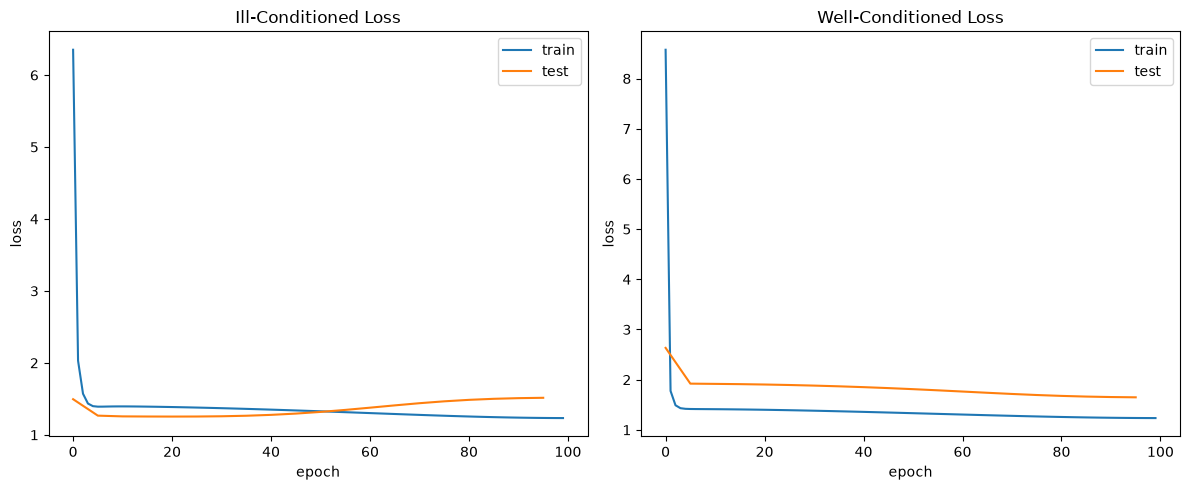

In [ ]:
# Loss curves

fig, (ax_loss_ill, ax_loss_well) = plt.subplots(1, 2, figsize=(12, 5))

ax_loss_ill.plot(list(range(EPOCHS)), trainer_ill.train_loss, label="train")
ax_loss_ill.plot(list(range(0, EPOCHS, EVAL_STEP)), trainer_ill.eval_loss, label="test")
ax_loss_ill.set_title("Ill-Conditioned Loss")
ax_loss_ill.set_xlabel("epoch")
ax_loss_ill.set_ylabel("loss")
ax_loss_ill.legend()

ax_loss_well.plot(list(range(EPOCHS)), trainer_well.train_loss, label='train')
ax_loss_well.plot(list(range(0, EPOCHS, EVAL_STEP)), trainer_well.eval_loss, label='test')
ax_loss_well.set_title("Well-Conditioned Loss")
ax_loss_well.set_xlabel("epoch")
ax_loss_well.set_ylabel("loss")
ax_loss_well.legend()

fig.tight_layout()
plt.show()

Both loss curves converge similarly — SGD has no trouble minimizing the training/test error on either dataset. This is the first hint that **prediction loss alone won't reveal the conditioning problem**; we need to look at the coefficients themselves.

In [ ]:
def model_coefs(model) -> np.ndarray:
    W, b = model.parameters[:]
    return np.vstack([W.data, b.data.reshape(1, -1)])

sgd_ill = model_coefs(model_ill)
sgd_well = model_coefs(model_well)

print('SGD coefficients (ill-conditioned data):\n', sgd_ill)
print('\nSGD coefficients (well-conditioned data):\n', sgd_well)
print('\nTrue coefficients:\n', coefs_true)

SGD coefficients (ill-conditioned data):
 [[0.8551126  0.10918301]
 [1.0929067  1.9220368 ]
 [1.7714964  2.1255305 ]]

SGD coefficients (well-conditioned data):
 [[ 1.9430937   0.00465567]
 [-0.08385872  2.034029  ]
 [ 1.8548306   2.0585396 ]]

True coefficients:
 [[2. 0.]
 [0. 2.]
 [2. 2.]]


## Comparing OLS vs. SGD

For each dataset, compare both fitting methods against the true coefficients on two axes:
- **Prediction residual** — `mse(predictions, true_function(X_test))`
- **Weight residual** — `mse(coefficients, true_coefficients)`

A method that fits the data well but recovers the wrong coefficients will show a low prediction residual alongside a high weight residual.

In [ ]:
from thorcino.functions import mse

def evaluate(coefs: np.ndarray, X_te: Tensor, preds: np.ndarray) -> tuple[float, float]:
    A_te = np.hstack([X_te.data, np.ones((X_te.shape[0], 1))])
    closed_form = A_te @ coefs_true
    pred_residual = mse(preds, closed_form)
    weight_residual = mse(coefs, coefs_true)
    return float(pred_residual), float(weight_residual)

ols_pred_ill = np.hstack([X_te_ill.data, np.ones((X_te_ill.shape[0], 1))]) @ ols_ill
sgd_pred_ill = model_ill(X_te_ill).data

ols_pred_well = np.hstack([X_te_well.data, np.ones((X_te_well.shape[0], 1))]) @ ols_well
sgd_pred_well = model_well(X_te_well).data

results = {
    ('ill', 'OLS'): evaluate(ols_ill, X_te_ill, ols_pred_ill),
    ('ill', 'SGD'): evaluate(sgd_ill, X_te_ill, sgd_pred_ill),
    ('well', 'OLS'): evaluate(ols_well, X_te_well, ols_pred_well),
    ('well', 'SGD'): evaluate(sgd_well, X_te_well, sgd_pred_well),
}

print(f'{"dataset":<6} {"method":<5} {"pred residual":>15} {"weight residual":>17}')
for (dataset, method), (pred_res, w_res) in results.items():
    print(f'{dataset:<6} {method:<5} {pred_res:>15.4f} {w_res:>17.4f}')

dataset method   pred residual   weight residual
ill    OLS            0.1522        18982.2187
ill    SGD            0.1439            0.4319
well   OLS            0.0376            0.0058
well   SGD            0.0376            0.0060


On the ill-conditioned dataset, both methods keep the prediction residual small, but OLS's weight residual is orders of magnitude larger than SGD's — the closed-form solution fits the data by cancelling two huge, oppositely-signed coefficients against each other. On the well-conditioned dataset both residuals are much smaller than in the ill-conditioned case for both methods — SGD's are somewhat higher than OLS's simply because it's an approximate, finite-iteration fit, not because of conditioning.

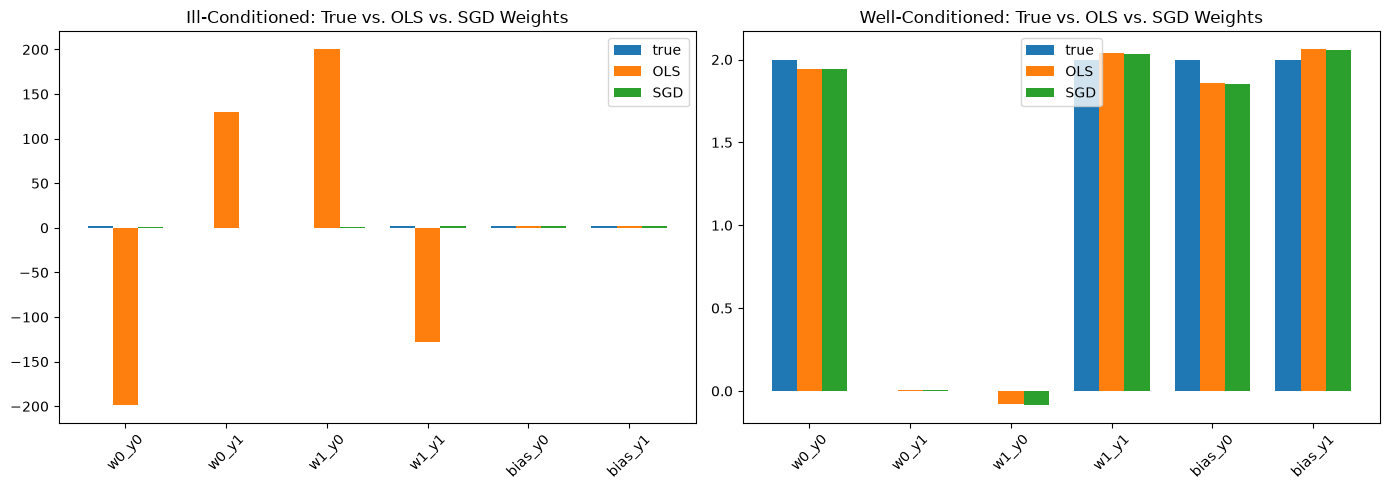

In [ ]:
"""Weights comparison: true vs. OLS vs. SGD"""

labels = ['w0_y0', 'w0_y1', 'w1_y0', 'w1_y1', 'bias_y0', 'bias_y1']
x = np.arange(len(labels))
width = 0.25

fig, (ax_w_ill, ax_w_well) = plt.subplots(1, 2, figsize=(14, 5))

ax_w_ill.bar(x - width, coefs_true.flatten(), width, label='true')
ax_w_ill.bar(x, ols_ill.flatten(), width, label='OLS')
ax_w_ill.bar(x + width, sgd_ill.flatten(), width, label='SGD')
ax_w_ill.set_title("Ill-Conditioned: True vs. OLS vs. SGD Weights")
ax_w_ill.set_xticks(x)
ax_w_ill.set_xticklabels(labels, rotation=45)
ax_w_ill.legend()

ax_w_well.bar(x - width, coefs_true.flatten(), width, label='true')
ax_w_well.bar(x, ols_well.flatten(), width, label='OLS')
ax_w_well.bar(x + width, sgd_well.flatten(), width, label='SGD')
ax_w_well.set_title("Well-Conditioned: True vs. OLS vs. SGD Weights")
ax_w_well.set_xticks(x)
ax_w_well.set_xticklabels(labels, rotation=45)
ax_w_well.legend()

fig.tight_layout()
plt.show()

## Coefficient Stability Under Resampling

A single fit isn't enough to judge stability — an unlucky (or lucky) noise draw could make either method look better or worse than it really is. To measure stability directly, redraw the noise on `y` many times, refit both OLS and SGD on each resample, and look at how much the estimated coefficients move around.

If ill-conditioning is the real culprit, OLS's coefficients should swing wildly across resamples while SGD's stay comparatively put — even though neither one perfectly recovers the true coefficients.

In [ ]:
"""Stability experiment: refit on many noisy resamples of the same X"""

N_TRIALS = 30

def resample_targets(X: np.ndarray, noise: float, rng: np.random.Generator) -> np.ndarray:
    return f(X) + rng.uniform(-1, 1, X.shape) * noise

def fit_sgd(X_tr: np.ndarray, y_tr: np.ndarray) -> np.ndarray:
    model = Sequential(Linear(2, 2))
    trainer = Trainer(model, MSELoss(), SGD(model.parameters, MAX_LR), CosineSchedule(MAX_LR, MIN_LR, EPOCHS))
    loader = DataLoader(TensorDataset(Tensor(X_tr), Tensor(y_tr)), len(X_tr))
    for _ in range(EPOCHS):
        trainer.train_epoch(loader, 1)
    return model_coefs(model)

X_tr_ill_arr, X_tr_well_arr = X_tr_ill.data, X_tr_well.data
ols_ill_trials, sgd_ill_trials = [], []
ols_well_trials, sgd_well_trials = [], []

for _ in range(N_TRIALS):
    y_ill_trial = resample_targets(X_tr_ill_arr, NOISE, rng)
    y_well_trial = resample_targets(X_tr_well_arr, NOISE, rng)

    ols_ill_trials.append(fit_ols(X_tr_ill_arr, y_ill_trial))
    sgd_ill_trials.append(fit_sgd(X_tr_ill_arr, y_ill_trial))

    ols_well_trials.append(fit_ols(X_tr_well_arr, y_well_trial))
    sgd_well_trials.append(fit_sgd(X_tr_well_arr, y_well_trial))

ols_ill_trials = np.array(ols_ill_trials)
sgd_ill_trials = np.array(sgd_ill_trials)
ols_well_trials = np.array(ols_well_trials)
sgd_well_trials = np.array(sgd_well_trials)

print('Coefficient std-dev across resamples (ill-conditioned data):')
print(f'  OLS: {ols_ill_trials.std(axis=0).mean():.2f}')
print(f'  SGD: {sgd_ill_trials.std(axis=0).mean():.4f}')
print('\nCoefficient std-dev across resamples (well-conditioned data):')
print(f'  OLS: {ols_well_trials.std(axis=0).mean():.4f}')
print(f'  SGD: {sgd_well_trials.std(axis=0).mean():.4f}')

Coefficient std-dev across resamples (ill-conditioned data):
  OLS: 786.01
  SGD: 0.3352

Coefficient std-dev across resamples (well-conditioned data):
  OLS: 0.0694
  SGD: 0.0493


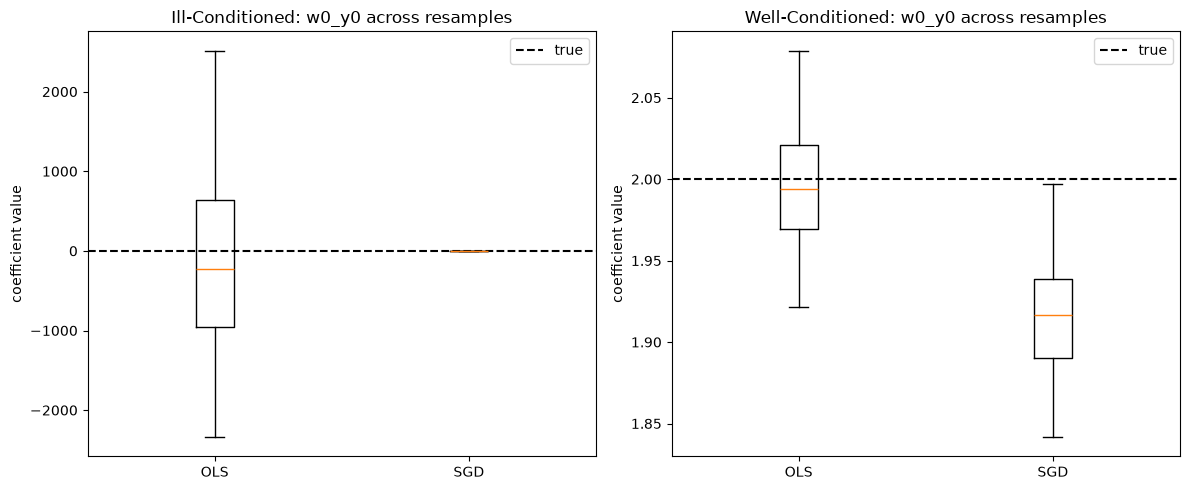

In [ ]:
"""Distribution of the w0_y0 coefficient across resamples"""

fig, (ax_ill, ax_well) = plt.subplots(1, 2, figsize=(12, 5))

ax_ill.boxplot(
    [ols_ill_trials[:, 0, 0], sgd_ill_trials[:, 0, 0]],
    tick_labels=['OLS', 'SGD']
)
ax_ill.axhline(coefs_true[0, 0], color='black', linestyle='--', label='true')
ax_ill.set_title("Ill-Conditioned: w0_y0 across resamples")
ax_ill.set_ylabel("coefficient value")
ax_ill.legend()

ax_well.boxplot(
    [ols_well_trials[:, 0, 0], sgd_well_trials[:, 0, 0]],
    tick_labels=['OLS', 'SGD']
)
ax_well.axhline(coefs_true[0, 0], color='black', linestyle='--', label='true')
ax_well.set_title("Well-Conditioned: w0_y0 across resamples")
ax_well.set_ylabel("coefficient value")
ax_well.legend()

fig.tight_layout()
plt.show()

# Conclusion

This experiment demonstrates the impact of ill-conditioned data on linear regression, and how OLS and SGD respond to it differently.

- **Prediction accuracy is not a reliable warning sign.** Both OLS and SGD fit the training/test data about equally well on the ill-conditioned dataset — the loss curves and prediction residuals look fine.
- **Closed-form OLS is far more fragile than SGD under multicollinearity.** With nearly collinear features, `(XᵀX)⁻¹` amplifies noise enormously (its condition number is the square of `X`'s), so OLS's coefficients swing by orders of magnitude across resamples of the same data. SGD, run for a fixed number of epochs, never takes the large steps needed to reach those extreme solutions — its early stopping acts as an implicit regularizer, giving noticeably more stable (though still not fully accurate) coefficients.
- **Neither method recovers the true coefficients when features are collinear.** The problem itself is nearly unidentifiable in that direction: many different coefficient pairs explain the data equally well. Stability is not the same as correctness.

### Why it matters

- In production, collinearity can break for any reason — a sensor outage, a shift in operating conditions — and a model whose coefficients were only "stable" by luck (or by an optimizer's implicit regularization) can behave very differently once that collinearity disappears.
- Whenever learned coefficients need to be *interpreted*, not just used for prediction, it's worth checking the conditioning of the input features — and worth knowing that the fitting method itself (closed-form vs. iterative) changes how much that ill-conditioning hurts.